In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Reading the data

In [3]:
RNDM_SEED = 42
np.random.seed(RNDM_SEED)
df = pd.read_csv('cluster_1_train_data.csv')
df.head()

,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Cluster_ID
0,2,0,0.571150,0.620148,0.624177,0.612275,0.612282,0.999163,0.797654,0.809533,...,0.006022,0.625306,0.612271,0.843294,0.278927,0.026816,0.565276,1,0.033034,1
1,9,0,0.522742,0.579536,0.575566,0.619114,0.619114,0.999075,0.797525,0.809443,...,0.002259,0.624266,0.619116,0.841468,0.275937,0.026791,0.565158,1,0.087300,1
2,13,0,0.590114,0.611753,0.634991,0.611403,0.611403,0.999206,0.797672,0.809558,...,0.009663,0.622830,0.611404,0.842483,0.275332,0.026791,0.565158,1,0.159042,1
3,14,0,0.501877,0.547700,0.562557,0.647782,0.647782,0.999076,0.797459,0.809416,...,0.000787,0.624350,0.647779,0.840367,0.276460,0.027138,0.566402,1,0.064648,1
4,16,0,0.480866,0.546991,0.529953,0.595994,0.594863,0.998926,0.797466,0.809373,...,0.007207,0.624691,0.595993,0.840578,0.276414,0.026797,0.565186,1,0.066087,1


In [4]:
y = df['Bankrupt?']
X = df.drop(columns = ['Index', 'Bankrupt?', 'Cluster_ID'])

print(f'shape of y: {y.shape}')
print(f'shape of X: {X.shape}')

shape of y: (1693,)
shape of X: (1693, 95)


### Preprocessing


In [5]:
rf = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = RNDM_SEED)
rf.fit(X, y)

imp = rf.feature_importances_ 
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)


top_features = feature_scores['Feature'].tolist()
print(top_features)

[' Inventory/Working Capital', ' Accounts Receivable Turnover', ' Total debt/Total net worth', ' Net Income to Total Assets', ' Net Value Per Share (A)', ' Net Value Per Share (B)', ' Liability to Equity', ' Operating Gross Margin', ' Inventory/Current Liability', ' Research and development expense rate', ' Degree of Financial Leverage (DFL)', ' CFO to Assets', ' Per Share Net profit before tax (Yuan ¥)', ' Net profit before tax/Paid-in capital', ' Revenue Per Share (Yuan ¥)', ' Average Collection Days', ' Current Liabilities/Equity', ' Working Capital to Total Assets', ' Retained Earnings to Total Assets', ' Total income/Total expense', ' Net Value Per Share (C)', ' Total Asset Turnover', ' Cash Flow Per Share', ' Operating profit per person', ' Cash Turnover Rate', ' Cash Flow to Equity', ' Current Liability to Assets', ' Net worth/Assets', ' Cash Flow to Liability', ' ROA(B) before interest and depreciation after tax', ' Realized Sales Gross Profit Growth Rate', " Net Income to Stoc

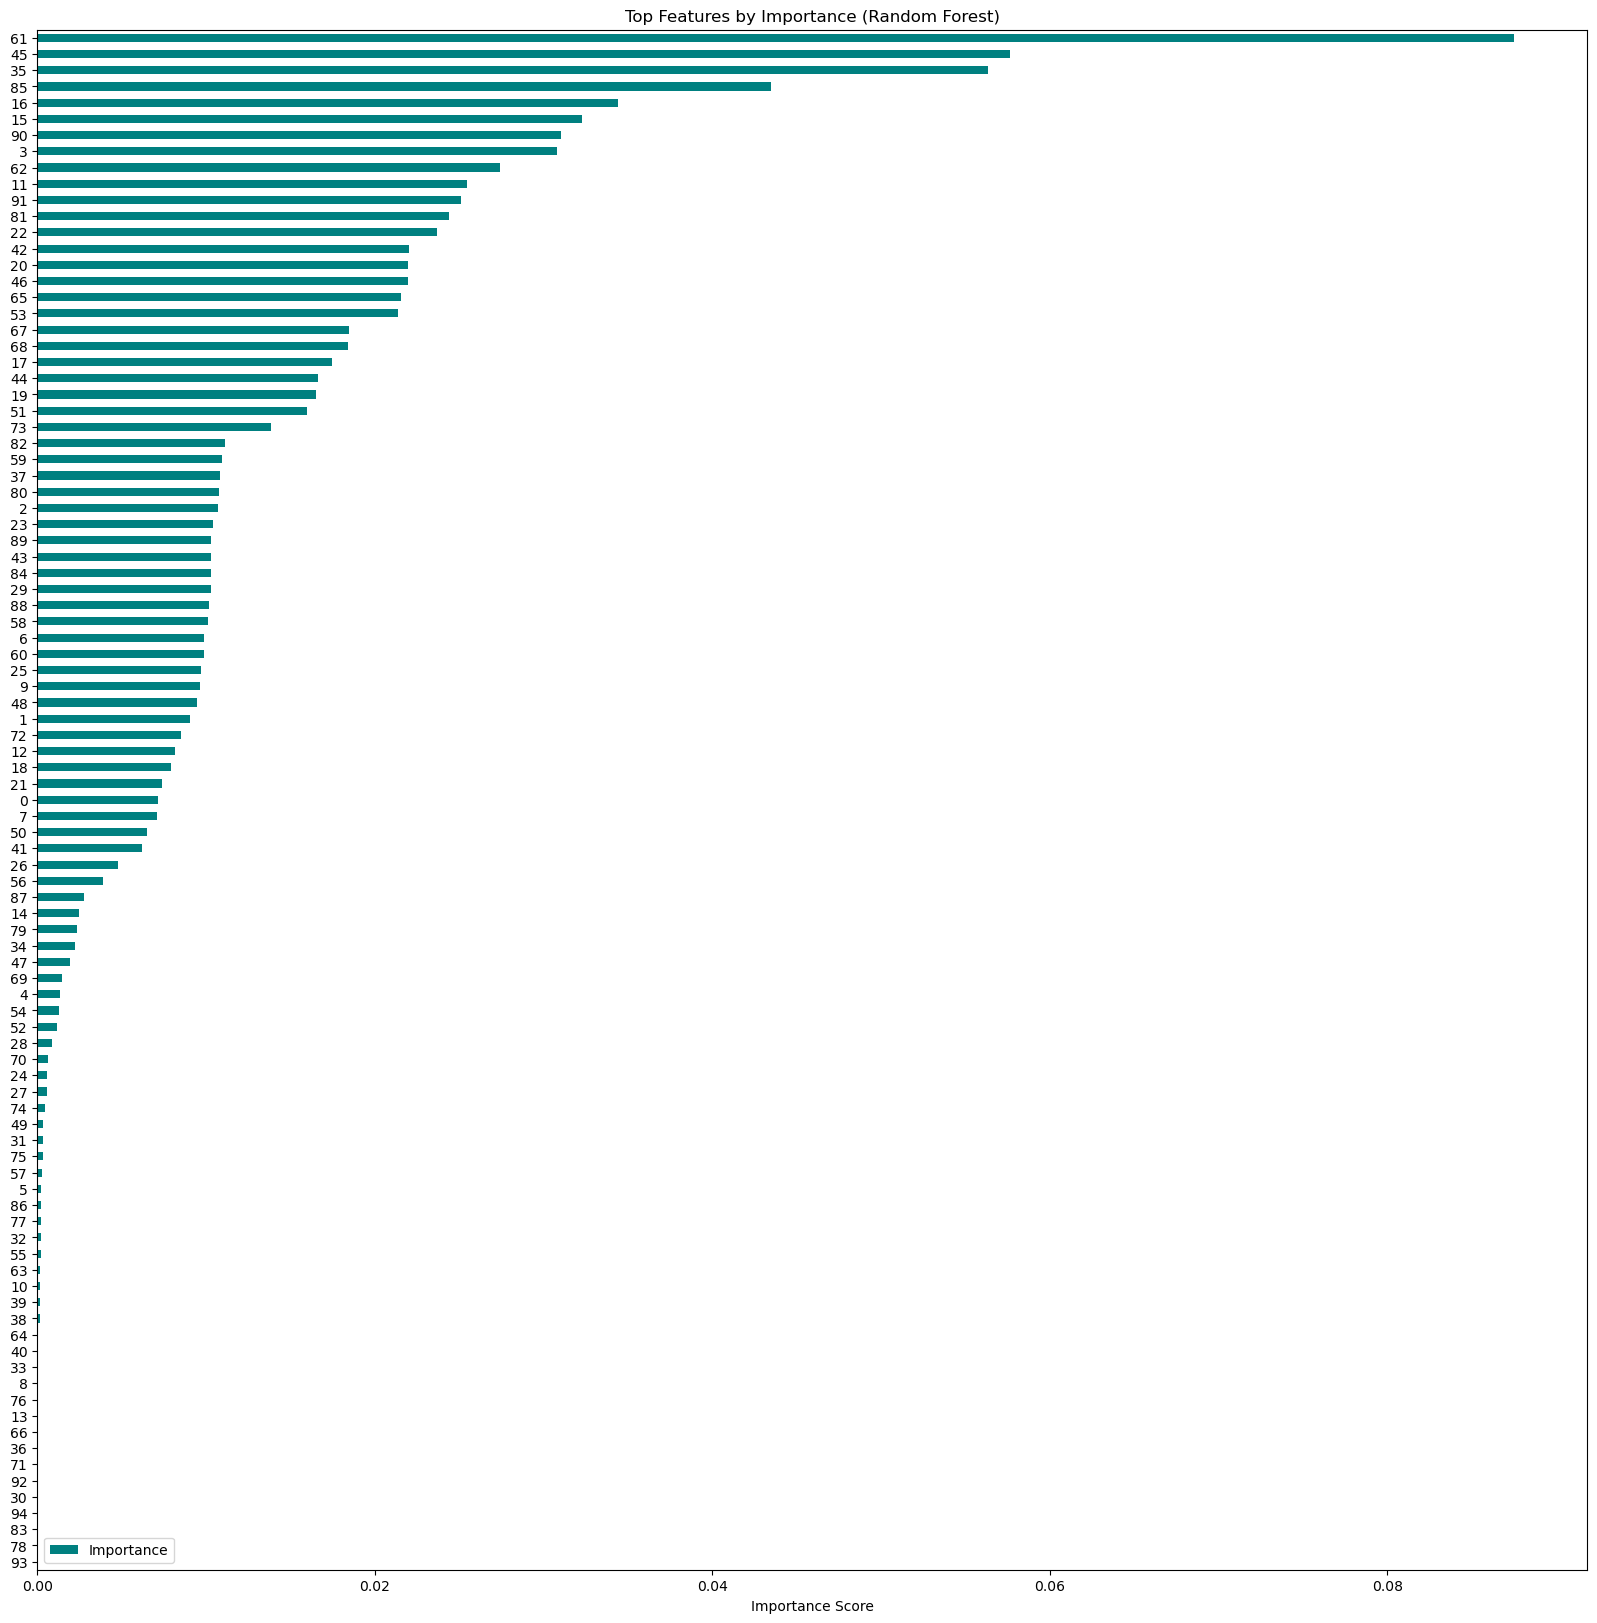

In [6]:
feature_scores.sort_values(by = 'Importance').plot(
    kind='barh', 
    color='teal', 
    figsize=(20, 20)
)

plt.title('Top Features by Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

Based on this plot, I think it only makes sense to keep features with importance scores more than 0.01

In [7]:
feature_scores.head()

,Feature,Importance
61,Inventory/Working Capital,0.087494
45,Accounts Receivable Turnover,0.057653
35,Total debt/Total net worth,0.056339
85,Net Income to Total Assets,0.043466
16,Net Value Per Share (A),0.034390


In [8]:
significant_features = feature_scores[feature_scores['Importance'] > 0.01]

In [9]:
significant_features.shape

(37, 2)

In [10]:
selected_cols = significant_features['Feature'].tolist()
top_X = X[selected_cols]

In [11]:
top_X.shape

(1693, 37)

In [12]:
# Lets check how many values actually are 1
ones = y.value_counts()
ones

Bankrupt?
0    1690
1       3
Name: count, dtype: int64

In [13]:
# Lets scale the data  
median_imputer = SimpleImputer(strategy='median')
X_no_missing = median_imputer.fit_transform(top_X)

std_scaler = StandardScaler()
X_final = std_scaler.fit_transform(X_no_missing)

n_features = X_final.shape[1]

X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size = 0.2, random_state = RNDM_SEED)

In [14]:
print(f'Shape of X_train is: {X_train.shape}')
print(f'Shape of X_val is: {X_val.shape}')
print(f'Shape of y_train is: {y_train.shape}')
print(f'Shape of y_val is: {y_val.shape}')

Shape of X_train is: (1354, 37)
Shape of X_val is: (339, 37)
Shape of y_train is: (1354,)
Shape of y_val is: (339,)


### Building model

In [15]:
class ConstantClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, prediction):
        self.prediction = prediction
    def fit(self, X, y): return self
    def predict(self, X): return np.full(X.shape[0], self.prediction)
    def predict_proba(self, X):
        if self.prediction == 1:
            return np.column_stack((np.zeros(X.shape[0]), np.ones(X.shape[0])))
        else:
            return np.column_stack((np.ones(X.shape[0]), np.zeros(X.shape[0])))

unique_classes = np.unique(y)
n_samples = len(y)

In [16]:
# Let's use random forest and logistic regression since they are robust to imbalance data
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators = 37, 
        random_state = RNDM_SEED, 
        class_weight = 'balanced'
    )),
    ('lr', LogisticRegression(
        random_state = RNDM_SEED, 
        class_weight = 'balanced', 
        max_iter = 1000
    ))
]
cv_folds = 5 if n_samples >= 20 else 2

clf = StackingClassifier(estimators = estimators,
                         final_estimator = LogisticRegression(),
                         cv=cv_folds,
                         n_jobs=-1)

clf.fit(X_train, y_train)
y_proba = clf.predict_proba(X_val)[:, 1]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix
Acc = 0
TP = 0
FN = 0
def get_constrained_threshold(y_true, y_proba, constraint=0.20):
    best_thresh = 0.05
    best_recall = -1
    thresholds = np.arange(0.1, 0.99, 0.05)
    
    print(f"\n--- Tuning Threshold (Max Positive Rate: {constraint:.0%}) ---")

    for thresh in thresholds:
        y_pred_loop = (y_proba >= thresh).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_loop, labels=[0,1]).ravel()
        Acc = tp /(tp + tn) 
        TP = tp
        FN = fn
    print(f" > FINAL Best Threshold: {best_thresh:.2f} (Recall: {best_recall:.3f})")
    return best_thresh

best_threshold = get_constrained_threshold(y_val, y_proba)



print(f"Final Accuracy: {Acc}")
print(f"Final TP: {TP}")
print(f"Final FN: {FN}")


--- Tuning Threshold (Max Positive Rate: 20%) ---
 > FINAL Best Threshold: 0.05 (Recall: -1.000)
Final Accuracy: 0
Final TP: 0
Final FN: 0


### Making predictions

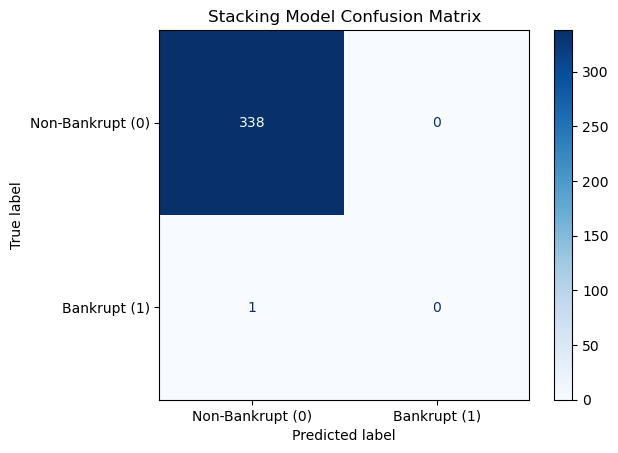

                        0
Subgroup_ID             1
Num_Companies        1693
Num_Bankrupt            3
Stacking_TT_Correct     0
Stacking_TF_Missed      0
N_Features             37


In [18]:
y_final_pred = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_final_pred, labels=[0,1])

results_data = {
    "Subgroup_ID": 1,
    "Num_Companies": len(y),
    "Num_Bankrupt": y.sum(),
    "Stacking_TT_Correct": TP,
    "Stacking_TF_Missed": FN,
    "N_Features": n_features
}

results_df = pd.DataFrame([results_data])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Bankrupt (0)", "Bankrupt (1)"])
disp.plot(cmap='Blues', values_format='d') 
plt.title("Stacking Model Confusion Matrix")
plt.show()
print(results_df.T)

In [19]:
print(f'Evaluating the base models')

# Access the dictionary of fitted base models
for name, model in clf.named_estimators_.items():
    print(f"\n--- Evaluating Base Model: {name.upper()} ---")
    
    base_proba = model.predict_proba(X_val)[:, 1]
    
    base_threshold = get_constrained_threshold(y_val, base_proba)
    
    base_final_pred = (base_proba >= base_threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_val, base_final_pred, labels=[0,1]).ravel()
    
    acc = (tp) / (tp + tn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"TP: {tp}")
    print(f"FN: {fn}")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"Recall: {recall:.2%}")
    print(f"Accuracy: {acc:.2%}")

Evaluating the base models

--- Evaluating Base Model: RF ---

--- Tuning Threshold (Max Positive Rate: 20%) ---
 > FINAL Best Threshold: 0.05 (Recall: -1.000)
TP: 0
FN: 1
TN: 338
FP: 0
Recall: 0.00%
Accuracy: 0.00%

--- Evaluating Base Model: LR ---

--- Tuning Threshold (Max Positive Rate: 20%) ---
 > FINAL Best Threshold: 0.05 (Recall: -1.000)
TP: 0
FN: 1
TN: 329
FP: 9
Recall: 0.00%
Accuracy: 0.00%


### Saving the model

In [20]:
model_bundle = {
    'model': clf,
    'scaler': std_scaler,
    'imputer': median_imputer,
    'threshold': best_threshold,
    'features': top_X.columns.tolist()
}
# Saving
fname = f"member_model_cluster_1.joblib"
joblib.dump(model_bundle, fname)
print(f"Saved: {fname}")

Saved: member_model_cluster_1.joblib
